# MLP Learning-to-Rank Pipeline for CV–JD Matching

This notebook implements a **Learning-to-Rank (LTR)** system for matching **CVs (candidates)** to **Job Descriptions (JDs)**.  
Instead of treating the task as plain classification, we **optimize ranking quality per CV**, ensuring relevant jobs are ranked higher than irrelevant ones.

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.models import Sequential
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Data Loading and Initial Cleaning

The dataset (`final_df_bgd_bgd.csv`) contains **pairwise CV–JD matches**, where:
- Each row = `(CV, JD)` pair
- `target ∈ {0,1}` indicates relevance

We drop **post-hoc scoring columns** (e.g. `final_score`, matched/missing weights) to avoid **label leakage**.

In [102]:
# Load and prepare data
df = pd.read_csv('final_df_bgd_bgd.csv')

# Data preparation
drop_cols = ['matched_weight', 'required_weight', 'missing_hard_skills',
             'missing_soft_skills', 'required_hard_skills', 'required_soft_skills',
             'missing_soft_skills_new', 'final_score']
df2 = df.drop(columns=drop_cols)

In [103]:
from sklearn.preprocessing import LabelEncoder

# Create label encoder
le = LabelEncoder()

# Fit and transform the domain column
df2['domain_encoded'] = le.fit_transform(df2['domain'])

df2 = df2.drop(columns=['domain'])

In [104]:
df.shape

(10176, 17)

In [105]:
df.columns

Index(['cv_id', 'jd_id', 'matched_weight', 'required_weight', 'match_ratio',
       'missing_required_skills_count', 'missing_hard_skills',
       'missing_soft_skills', 'required_hard_skills', 'required_soft_skills',
       'required_skill_count', 'soft_skill_match_score',
       'missing_soft_skills_new', 'missing_soft_skills_count_new', 'domain',
       'final_score', 'target'],
      dtype='object')

In [106]:
df['cv_id'].nunique()

32

In [107]:
df['jd_id'].nunique()

318

In [108]:
df['target'].value_counts()

,count
target,
0,7809
1,2367


In [109]:
df.isnull().sum()

,0
cv_id,0
jd_id,0
matched_weight,0
required_weight,0
match_ratio,0
missing_required_skills_count,0
missing_hard_skills,0
missing_soft_skills,0
required_hard_skills,0
required_soft_skills,0


In [110]:
df2.head()

,cv_id,jd_id,match_ratio,missing_required_skills_count,required_skill_count,soft_skill_match_score,missing_soft_skills_count_new,target,domain_encoded
0,1,1,1.000000,0,5,0.779042,0,1,12
1,1,2,0.750000,1,6,0.576355,1,1,8
2,1,3,0.333333,2,6,0.757210,0,0,2
3,1,4,0.333333,2,9,0.698309,1,0,2
4,1,5,0.625000,3,18,0.710335,2,1,2


In [111]:
df2.columns

Index(['cv_id', 'jd_id', 'match_ratio', 'missing_required_skills_count',
       'required_skill_count', 'soft_skill_match_score',
       'missing_soft_skills_count_new', 'target', 'domain_encoded'],
      dtype='object')

In [112]:
feature_cols = [col for col in df2.columns if col not in ['cv_id', 'jd_id', 'target']]
target_col = 'target'

In [113]:
correlations = df2[feature_cols].corrwith(df2[target_col]).sort_values(ascending=False)
corr_matrix = df2[feature_cols].corr()

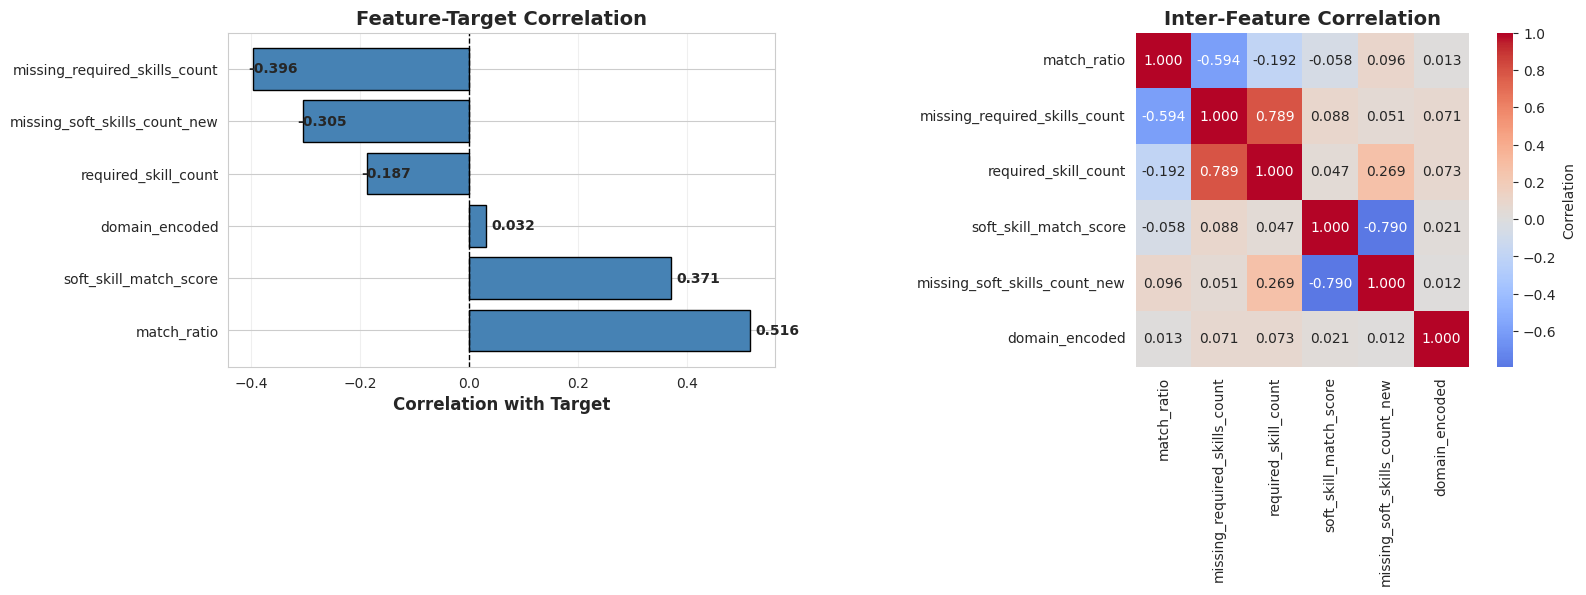

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation with target
axes[0].barh(correlations.index, correlations.values, color='steelblue', edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Correlation with Target', fontsize=12, fontweight='bold')
axes[0].set_title('Feature-Target Correlation', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add correlation values as text
for i, (feat, val) in enumerate(correlations.items()):
    axes[0].text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:.3f}',
                 va='center', fontweight='bold')

# Inter-feature correlation heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Inter-Feature Correlation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [115]:
# Create interaction features
df2['skill_match_product'] = df2['match_ratio'] * df2['soft_skill_match_score']
df2['total_missing_skills'] = df2['missing_required_skills_count'] + df2['missing_soft_skills_count_new']
df2['skill_completeness'] = 1 / (1 + df2['total_missing_skills'])
df2['hard_soft_ratio'] = df2['match_ratio'] / (df2['soft_skill_match_score'] + 0.01)
df2['hard_skill_squared'] = df2['match_ratio'] ** 2
df2['soft_skill_squared'] = df2['soft_skill_match_score'] ** 2

# Drop highly correlated feature
df2 = df2.drop(columns=['skill_match_product'])

In [116]:
# Define columns
id_cols = ['cv_id', 'jd_id']
target_col = 'target'
feature_cols = [col for col in df2.columns if col not in id_cols + [target_col]]

# Prepare data
X = df2[feature_cols].copy()
y = df2[target_col].copy()
groups = df2['cv_id'].copy()

**Important:** Only ~32 CVs exist → evaluation must be **group-aware** to avoid leakage.

## Group-Aware Train / Validation / Test Split

We use **GroupShuffleSplit** with `cv_id` as the group.

This ensures:
\[
\text{CV}_{train} \cap \text{CV}_{val} \cap \text{CV}_{test} = \emptyset
\]

Two-stage split:
- 65% Train
- 17.5% Validation
- 17.5% Test

This prevents **CV memorization**.

In [117]:
# Split data
gss1 = GroupShuffleSplit(test_size=0.35, n_splits=1, random_state=1000)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]
cv_train = groups.iloc[train_idx]

X_ = X.iloc[temp_idx]
y_ = y.iloc[temp_idx]
cv_ = groups.iloc[temp_idx]

In [118]:
gss2 = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=2024)
test_idx, val_idx = next(gss2.split(X_, y_, groups=cv_))

X_test = X_.iloc[test_idx]
y_test = y_.iloc[test_idx]
cv_test = cv_.iloc[test_idx]

X_val = X_.iloc[val_idx]
y_val = y_.iloc[val_idx]
cv_val = cv_.iloc[val_idx]

In [119]:
# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [120]:
# Clear session
keras.backend.clear_session()


## Ranking Matrices

### 9.1 Ranking Function

For each CV:
1. Predict relevance scores
2. Sort JDs by descending score

Produces a **ranking matrix**:
$$
\text{Rank}_{cv} = [jd_1, jd_2, \dots]
$$


In [121]:
def rank(X, y_true, cv, model):
    """
    Rank job descriptions for each CV based on model predictions
    """
    if isinstance(model, keras.Model):
        X_scores = model.predict(X, verbose=0).flatten()
    else:
        X_scores = model.predict_proba(X)[:, 1]

    X_rank_df = X.copy()
    X_rank_df['cv_id'] = cv.values
    X_rank_df['score'] = X_scores
    X_rank_df['target'] = y_true.values
    X_rank_df = X_rank_df.sort_values(
        by=['cv_id', 'score'],
        ascending=[True, False]
    )
    return X_rank_df


### 9.2 Mean Reciprocal Rank (MRR)

For CV \( c \):
$$
\text{RR}_c = \frac{1}{\text{rank of first relevant JD}}
$$

Overall:
$$
\text{MRR} = \frac{1}{|C|} \sum_c \text{RR}_c
$$

Measures **how early the first correct match appears**.

In [122]:
def mean_reciprocal_rank(df):
    """
    Calculate Mean Reciprocal Rank (MRR)
    """
    rr = []
    for cv, group in df.groupby('cv_id'):
        group = group.reset_index(drop=True)
        relevant = group[group['target'] == 1]

        if len(relevant) == 0:
            continue

        first_rank = relevant.index[0] + 1
        rr.append(1 / first_rank)

    return sum(rr) / len(rr) if len(rr) > 0 else 0.0

### 9.3 Precision@K

$$
P@K = \frac{\text{relevant JDs in top K}}{K}
$$

Averaged across CVs.

In [123]:
def precision_at_k(df, k):
    """
    Calculate Precision@k
    """
    precisions = []
    for cv, group in df.groupby('cv_id'):
        top_k = group.head(k)
        precisions.append(top_k['target'].mean())

    return sum(precisions) / len(precisions) if len(precisions) > 0 else 0.0

## Custom Ranking Callback

During training, after **each epoch**, we:
- Rank JDs per CV
- Compute MRR, P@5, P@10
- Track **generalization gap**

This aligns training monitoring with the **actual ranking objective**.

In [124]:
class RankingMetricsCallback(callbacks.Callback):
    """
    Custom callback to track MRR and Precision@k during training
    """
    def __init__(self, X_train, y_train, cv_train, X_val, y_val, cv_val):
        super().__init__()
        self.X_train = X_train
        self.y_train = y_train
        self.cv_train = cv_train
        self.X_val = X_val
        self.y_val = y_val
        self.cv_val = cv_val

        # Initialize history
        self.history_data = {
            'train_mrr': [],
            'val_mrr': [],
            'train_p@5': [],
            'val_p@5': [],
            'train_p@10': [],
            'val_p@10': []
        }

    def on_epoch_end(self, epoch, logs=None):
        # Calculate training metrics
        train_rank = rank(self.X_train, self.y_train, self.cv_train, self.model)
        train_mrr = mean_reciprocal_rank(train_rank)
        train_p5 = precision_at_k(train_rank, k=5)
        train_p10 = precision_at_k(train_rank, k=10)

        # Calculate validation metrics
        val_rank = rank(self.X_val, self.y_val, self.cv_val, self.model)
        val_mrr = mean_reciprocal_rank(val_rank)
        val_p5 = precision_at_k(val_rank, k=5)
        val_p10 = precision_at_k(val_rank, k=10)

        # Store metrics
        self.history_data['train_mrr'].append(train_mrr)
        self.history_data['val_mrr'].append(val_mrr)
        self.history_data['train_p@5'].append(train_p5)
        self.history_data['val_p@5'].append(val_p5)
        self.history_data['train_p@10'].append(train_p10)
        self.history_data['val_p@10'].append(val_p10)

        # Print metrics
        print(f"\nEpoch {epoch + 1}:")
        print(f"  Train MRR: {train_mrr:.4f} | Val MRR: {val_mrr:.4f}")
        print(f"  Train P@5: {train_p5:.4f} | Val P@5: {val_p5:.4f}")
        print(f"  Train P@10: {train_p10:.4f} | Val P@10: {val_p10:.4f}")

In [125]:
keras.backend.clear_session()

## Pairwise Ranking Hinge Loss

We use a **pairwise hinge loss**:

For every positive–negative pair:
$$
\mathcal{L} = \max(0, m - (s^+ - s^-))
$$

Where:
- $$ s^+  = score of relevant JD $$
- $$s^- = score of irrelevant JD  $$
-  $$ m  = margin  $$

The loss averages over all valid pairs:
$$
\mathcal{L}_{rank} = \frac{1}{|P|} \sum \mathcal{L}
$$

This directly enforces **ordering**, not probability calibration.


In [126]:
def ranking_hinge_loss(y_true, y_pred, margin=1.0):
    """Simplified hinge loss for ranking"""
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    pos_mask = tf.cast(tf.equal(y_true, 1), tf.float32)
    neg_mask = tf.cast(tf.equal(y_true, 0), tf.float32)

    pos_scores = y_pred * pos_mask
    neg_scores = y_pred * neg_mask

    pos_scores_expanded = tf.expand_dims(pos_scores, 1)
    neg_scores_expanded = tf.expand_dims(neg_scores, 0)

    score_diffs = pos_scores_expanded - neg_scores_expanded
    losses = tf.maximum(0.0, margin - score_diffs)

    valid_pairs = tf.expand_dims(pos_mask, 1) * tf.expand_dims(neg_mask, 0)
    masked_losses = losses * valid_pairs
    num_valid_pairs = tf.reduce_sum(valid_pairs) + 1e-10

    return tf.reduce_sum(masked_losses) / num_valid_pairs

In [127]:
input_dim = X_train_scaled.shape[1]
l2_reg = 0.5
dropout_rate = 0.6

In [128]:
model = Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg),
        bias_regularizer=regularizers.l2(l2_reg)
    ),
    layers.BatchNormalization(),
    layers.Dropout(dropout_rate),
    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg),
        bias_regularizer=regularizers.l2(l2_reg)
    ),
    layers.BatchNormalization(),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation='sigmoid')
])

In [129]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss=ranking_hinge_loss,
    metrics=[keras.metrics.AUC(name='auc')]
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 192 (768.00 B)

None


## Training Callbacks

- **EarlyStopping** on validation AUC
- **ReduceLROnPlateau**
- **RankingMetricsCallback**

In [130]:
ranking_callback = RankingMetricsCallback(
    X_train_scaled, y_train, cv_train,
    X_val_scaled, y_val, cv_val
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    mode='max',
    verbose=1
)






## Class Imbalance Handling

Positive samples are rare.

We compute:
$$
w_1 = \frac{1}{\text{positive ratio}} - 1
$$

Used as **class weights** to penalize false negatives.

---



In [131]:
# Class weights
class_weight_ratio = (1 / y_train.mean()) - 1
class_weight = {0: 1.0, 1: class_weight_ratio}
print(f"\nPositive class ratio: {y_train.mean():.4f}")
print(f"Class weights: {class_weight}")


Positive class ratio: 0.2181
Class weights: {0: 1.0, 1: np.float64(3.585436193222783)}


In [132]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[ranking_callback, early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.4696 - loss: 28.7758
Epoch 1:
  Train MRR: 0.7357 | Val MRR: 0.6528
  Train P@5: 0.6700 | Val P@5: 0.5000
  Train P@10: 0.6800 | Val P@10: 0.4833
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - auc: 0.4706 - loss: 28.6722 - val_auc: 0.8374 - val_loss: 18.2477 - learning_rate: 5.0000e-04
Epoch 2/100
 93/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6728 - loss: 16.7098
Epoch 2:
  Train MRR: 0.7238 | Val MRR: 0.6944
  Train P@5: 0.7300 | Val P@5: 0.6667
  Train P@10: 0.7600 | Val P@10: 0.6500
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.6750 - loss: 16.5445 - val_auc: 0.9137 - val_loss: 10.3493 - learning_rate: 5.0000e-04
Epoch 3/100
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8021 - loss: 9.4762
Epoch 3:
  Train MRR: 0.7667 | Val MRR: 0.7500
  Train P@5: 0.8100 | Val P@5: 0.7333
  Train P@10: 0.8000 | Val P@10: 0.6833
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.8028 - loss: 9.4279 - val_auc: 0.9289 - val_loss: 

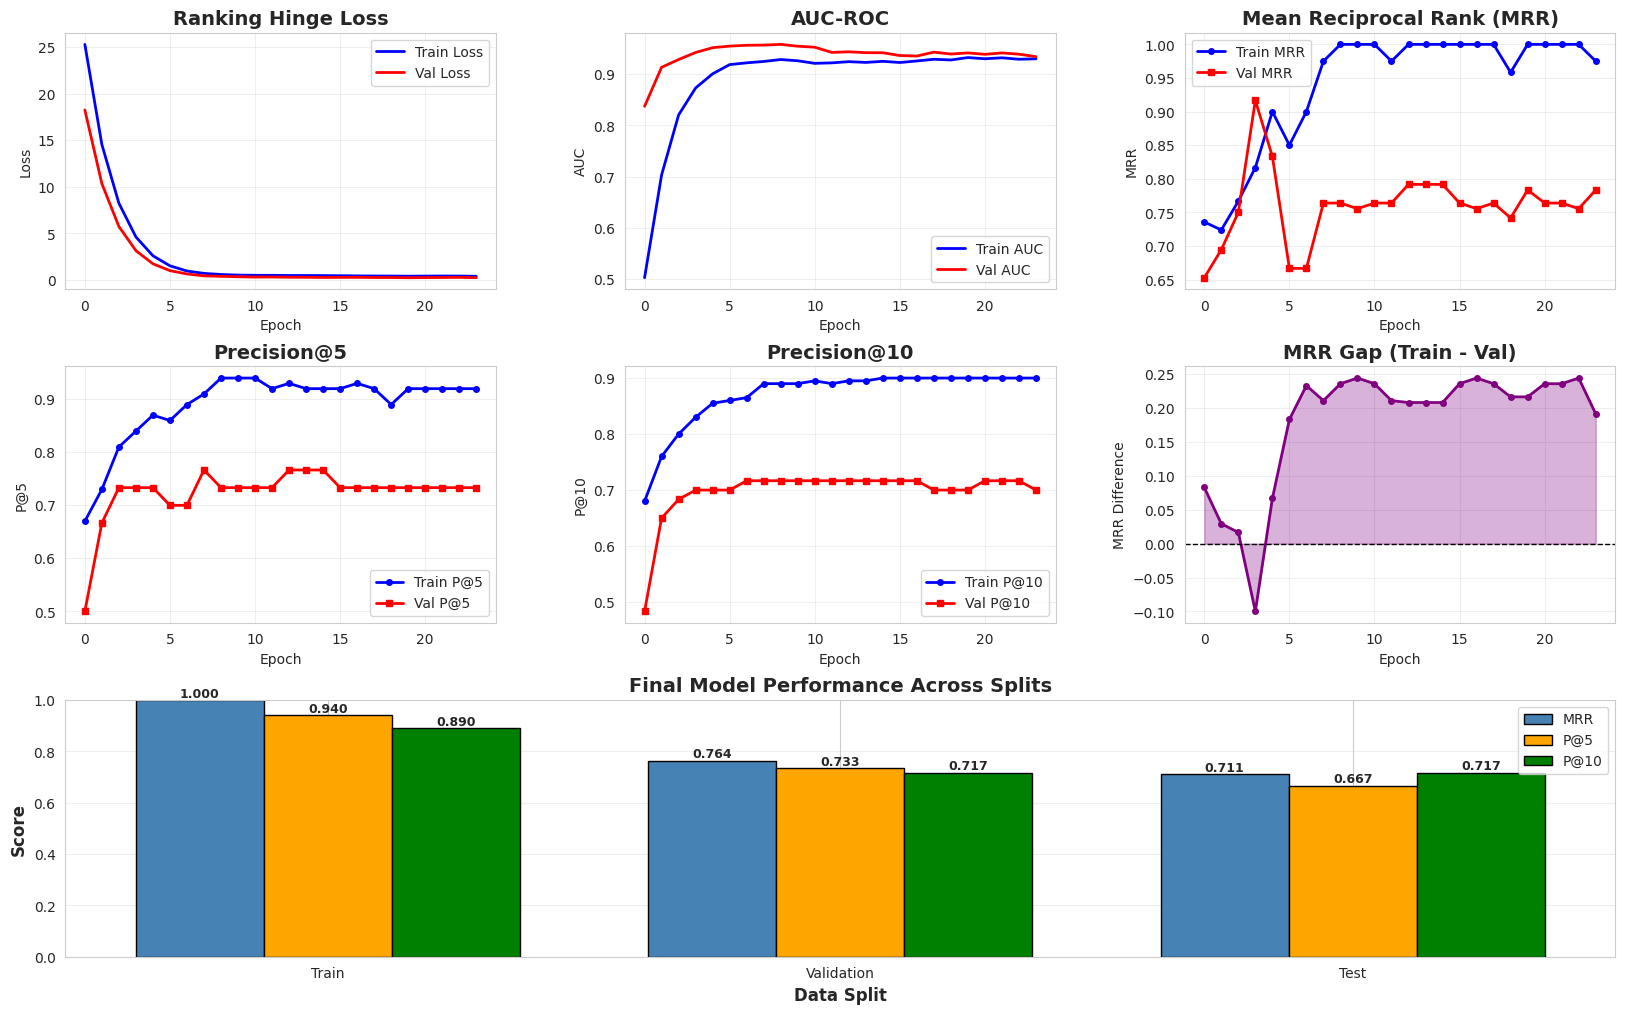

In [133]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Loss Curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='red')
ax1.set_title('Ranking Hinge Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. AUC Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['auc'], label='Train AUC', linewidth=2, color='blue')
ax2.plot(history.history['val_auc'], label='Val AUC', linewidth=2, color='red')
ax2.set_title('AUC-ROC', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. MRR Learning Curve (Train vs Val)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(ranking_callback.history_data['train_mrr'], label='Train MRR', linewidth=2, color='blue', marker='o', markersize=4)
ax3.plot(ranking_callback.history_data['val_mrr'], label='Val MRR', linewidth=2, color='red', marker='s', markersize=4)
ax3.set_title('Mean Reciprocal Rank (MRR)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('MRR')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Precision@5 Learning Curve
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(ranking_callback.history_data['train_p@5'], label='Train P@5', linewidth=2, color='blue', marker='o', markersize=4)
ax4.plot(ranking_callback.history_data['val_p@5'], label='Val P@5', linewidth=2, color='red', marker='s', markersize=4)
ax4.set_title('Precision@5', fontsize=14, fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('P@5')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Precision@10 Learning Curve
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(ranking_callback.history_data['train_p@10'], label='Train P@10', linewidth=2, color='blue', marker='o', markersize=4)
ax5.plot(ranking_callback.history_data['val_p@10'], label='Val P@10', linewidth=2, color='red', marker='s', markersize=4)
ax5.set_title('Precision@10', fontsize=14, fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('P@10')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. MRR Gap (Train - Val)
ax6 = fig.add_subplot(gs[1, 2])
mrr_gap = [t - v for t, v in zip(ranking_callback.history_data['train_mrr'], ranking_callback.history_data['val_mrr'])]
ax6.plot(mrr_gap, linewidth=2, color='purple', marker='o', markersize=4)
ax6.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax6.set_title('MRR Gap (Train - Val)', fontsize=14, fontweight='bold')
ax6.set_xlabel('Epoch')
ax6.set_ylabel('MRR Difference')
ax6.grid(True, alpha=0.3)
ax6.fill_between(range(len(mrr_gap)), mrr_gap, alpha=0.3, color='purple')

# 7. Final Test Set Performance - Bar Chart
ax7 = fig.add_subplot(gs[2, :])

# Calculate final metrics on all splits
train_rank_final = rank(X_train_scaled, y_train, cv_train, model)
val_rank_final = rank(X_val_scaled, y_val, cv_val, model)
test_rank_final = rank(X_test_scaled, y_test, cv_test, model)

train_mrr_final = mean_reciprocal_rank(train_rank_final)
val_mrr_final = mean_reciprocal_rank(val_rank_final)
test_mrr_final = mean_reciprocal_rank(test_rank_final)

train_p5_final = precision_at_k(train_rank_final, k=5)
val_p5_final = precision_at_k(val_rank_final, k=5)
test_p5_final = precision_at_k(test_rank_final, k=5)

train_p10_final = precision_at_k(train_rank_final, k=10)
val_p10_final = precision_at_k(val_rank_final, k=10)
test_p10_final = precision_at_k(test_rank_final, k=10)

splits = ['Train', 'Validation', 'Test']
mrr_scores = [train_mrr_final, val_mrr_final, test_mrr_final]
p5_scores = [train_p5_final, val_p5_final, test_p5_final]
p10_scores = [train_p10_final, val_p10_final, test_p10_final]

x = np.arange(len(splits))
width = 0.25

bars1 = ax7.bar(x - width, mrr_scores, width, label='MRR', color='steelblue', edgecolor='black')
bars2 = ax7.bar(x, p5_scores, width, label='P@5', color='orange', edgecolor='black')
bars3 = ax7.bar(x + width, p10_scores, width, label='P@10', color='green', edgecolor='black')

ax7.set_xlabel('Data Split', fontsize=12, fontweight='bold')
ax7.set_ylabel('Score', fontsize=12, fontweight='bold')
ax7.set_title('Final Model Performance Across Splits', fontsize=14, fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(splits)
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')
ax7.set_ylim([0, 1.0])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

In [134]:
print("MODEL PERFORMANCE SUMMARY")

print(f"\n{'Metric':<20} {'Train':<15} {'Validation':<15} {'Test':<15}")
print("-"*70)
print(f"{'MRR':<20} {train_mrr_final:<15.4f} {val_mrr_final:<15.4f} {test_mrr_final:<15.4f}")
print(f"{'Precision@5':<20} {train_p5_final:<15.4f} {val_p5_final:<15.4f} {test_p5_final:<15.4f}")
print(f"{'Precision@10':<20} {train_p10_final:<15.4f} {val_p10_final:<15.4f} {test_p10_final:<15.4f}")
print(f"{'AUC':<20} {history.history['auc'][-1]:<15.4f} {history.history['val_auc'][-1]:<15.4f} {roc_auc_score(y_test, model.predict(X_test_scaled)):<15.4f}")

print("\n" + "="*70)
print(f"Training completed in {len(history.history['loss'])} epochs")
print(f"Best epoch (by validation AUC): {np.argmax(history.history['val_auc']) + 1}")
print("="*70)

MODEL PERFORMANCE SUMMARY

Metric               Train           Validation      Test           
----------------------------------------------------------------------
MRR                  1.0000          0.7639          0.7111         
Precision@5          0.9400          0.7333          0.6667         
Precision@10         0.8900          0.7167          0.7167         
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
AUC                  0.9303          0.9345          0.9711         

Training completed in 24 epochs
Best epoch (by validation AUC): 9


## Problem: Overfitting!**

From the previous run, we observed:

1. **Train-Validation Gap:**
   - Train MRR: 0.975 (near perfect)
   - Validation MRR: 0.764 (significant drop)
   - Test MRR: 0.628 (further degradation)

2. **Root Causes:**
   - **Small Dataset**: Only 32 CVs total (~10 train, ~5-6 val, ~5-6 test groups)
   - **Model Complexity**: 2 hidden layers (64→32 neurons)
   - **Feature Memorization**: Model learned CV-specific patterns rather than generalizable ranking rules
   - **Wrong Early Stopping Metric detected**


### **Down I will try to solve it**
by choosing a lighter model with less neurons and hidden layers and change stopping critria matric

In [135]:
input_dim = X_train_scaled.shape[1]
l2_reg = 0.5
dropout_rate = 0.6

In [136]:
model = Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg),
        bias_regularizer=regularizers.l2(l2_reg)
    ),
    layers.BatchNormalization(),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation='sigmoid')
])

In [137]:
model = Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg),
        bias_regularizer=regularizers.l2(l2_reg)
    ),
    layers.BatchNormalization(),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation='sigmoid')
])

In [138]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss=ranking_hinge_loss,
    metrics=[keras.metrics.AUC(name='auc')]
)

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 64 (256.00 B)

None


In [139]:
# Custom Early Stopping based on MRR
class EarlyStoppingMRR(callbacks.Callback):
    """Early stopping based on validation MRR"""
    def __init__(self, patience=10, min_delta=0.001):
        super().__init__()
        self.patience = patience
        self.min_delta = min_delta
        self.best_mrr = 0
        self.wait = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        # Get current val MRR from ranking callback
        current_mrr = ranking_callback.history_data['val_mrr'][-1]

        if current_mrr > self.best_mrr + self.min_delta:
            self.best_mrr = current_mrr
            self.wait = 0
            self.best_weights = self.model.get_weights()
            print(f"  ✓ New best Val MRR: {current_mrr:.4f}")
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\nEarly stopping triggered! No improvement for {self.patience} epochs.")
                print(f"  Best Val MRR: {self.best_mrr:.4f}")
                self.model.stop_training = True
                if self.best_weights is not None:
                    print("  Restoring best weights...")
                    self.model.set_weights(self.best_weights)

In [140]:
early_stopping_mrr = EarlyStoppingMRR(patience=10, min_delta=0.001)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    mode='max',
    verbose=1
)

In [141]:
# Class weights
class_weight_ratio = (1 / y_train.mean()) - 1
class_weight = {0: 1.0, 1: class_weight_ratio}
print(f"\nPositive class ratio: {y_train.mean():.4f}")
print(f"Class weights: {class_weight}")


Positive class ratio: 0.2181
Class weights: {0: 1.0, 1: np.float64(3.585436193222783)}


In [142]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[ranking_callback, early_stopping_mrr, reduce_lr],
    verbose=1
)

Epoch 1/100
 83/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.6541 - loss: 8.6446
Epoch 1:
  Train MRR: 0.8825 | Val MRR: 0.7833
  Train P@5: 0.8000 | Val P@5: 0.7000
  Train P@10: 0.7950 | Val P@10: 0.6667
  ✓ New best Val MRR: 0.7833
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - auc: 0.6630 - loss: 8.5056 - val_auc: 0.9240 - val_loss: 5.8920 - learning_rate: 5.0000e-04
Epoch 2/100
 86/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8000 - loss: 5.9251
Epoch 2:
  Train MRR: 0.8892 | Val MRR: 0.8667
  Train P@5: 0.8300 | Val P@5: 0.7000
  Train P@10: 0.8100 | Val P@10: 0.6833
  ✓ New best Val MRR: 0.8667
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc: 0.8031 - loss: 5.8460 - val_auc: 0.9390 - val_loss: 4.0036 - learning_rate: 5.0000e-04
Epoch 3/100
 95/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.8747 - loss: 4.0230
Epoch 3:
  Train MRR: 0.9083 | Val MRR: 0.8889
  Train P@5: 0.8700 | Val P@5: 0.7333
  Train P@10: 0.8200 | Val P@10: 0.6833
  ✓ New best Val MRR: 0.8889
100/100 ━━━━━━━━━━━━

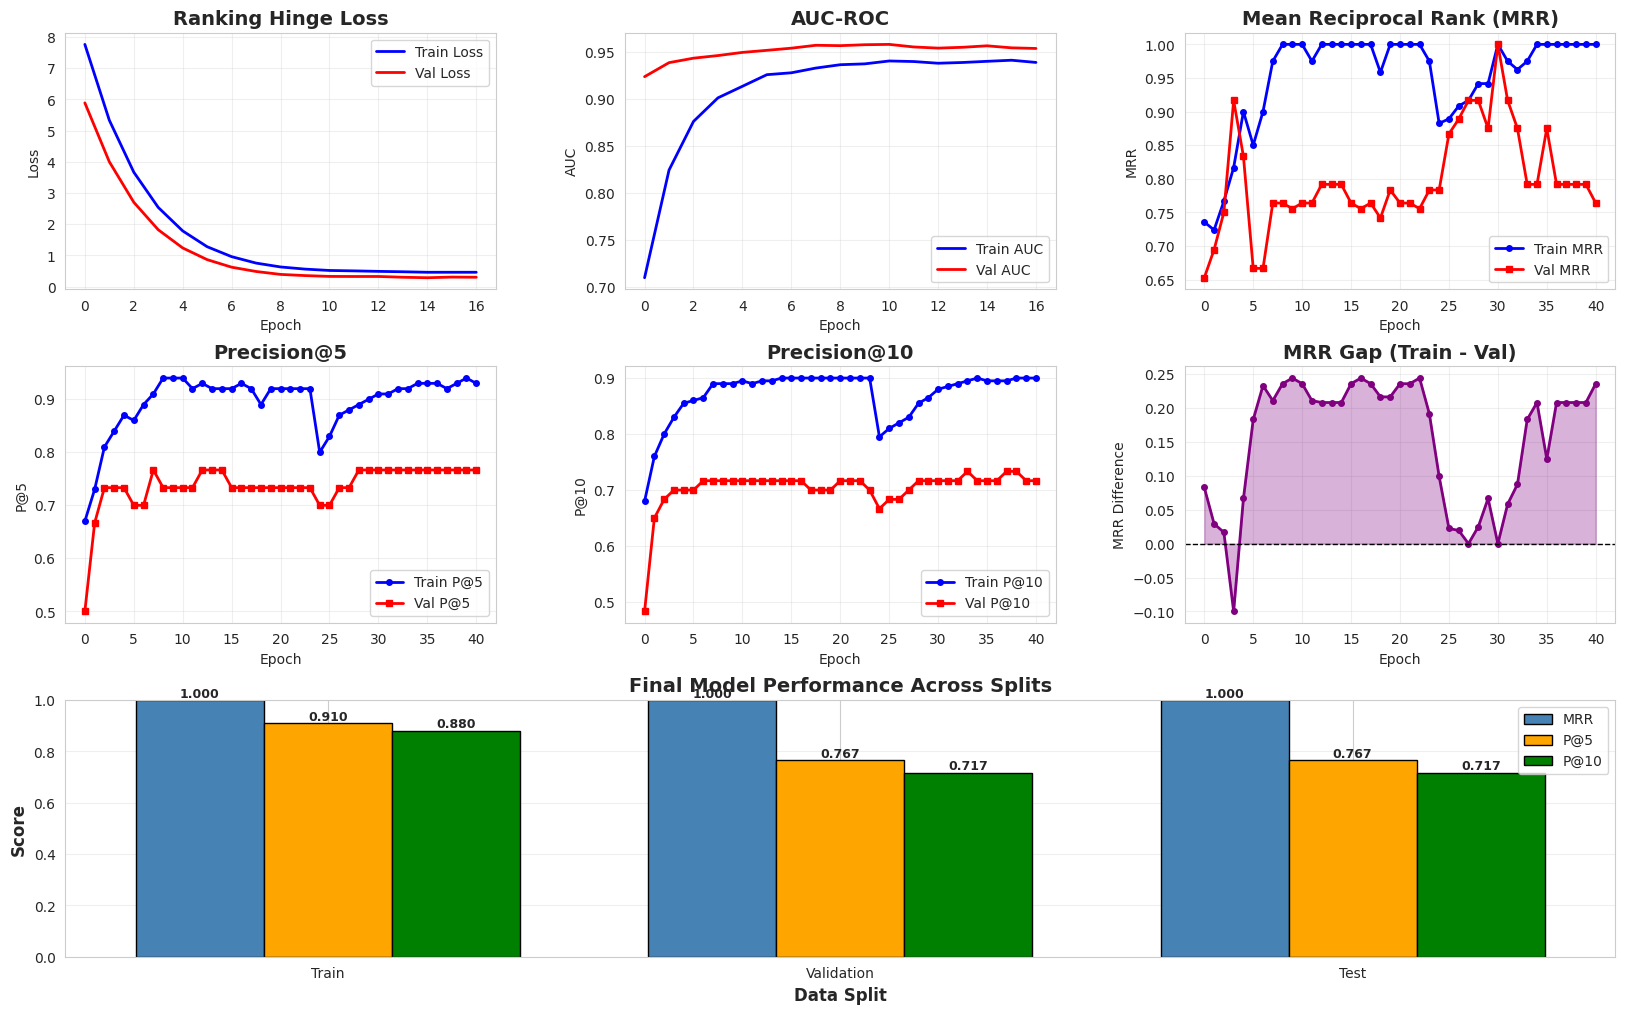

In [143]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Loss Curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='red')
ax1.set_title('Ranking Hinge Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. AUC Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['auc'], label='Train AUC', linewidth=2, color='blue')
ax2.plot(history.history['val_auc'], label='Val AUC', linewidth=2, color='red')
ax2.set_title('AUC-ROC', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. MRR Learning Curve (Train vs Val)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(ranking_callback.history_data['train_mrr'], label='Train MRR', linewidth=2, color='blue', marker='o', markersize=4)
ax3.plot(ranking_callback.history_data['val_mrr'], label='Val MRR', linewidth=2, color='red', marker='s', markersize=4)
ax3.set_title('Mean Reciprocal Rank (MRR)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('MRR')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Precision@5 Learning Curve
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(ranking_callback.history_data['train_p@5'], label='Train P@5', linewidth=2, color='blue', marker='o', markersize=4)
ax4.plot(ranking_callback.history_data['val_p@5'], label='Val P@5', linewidth=2, color='red', marker='s', markersize=4)
ax4.set_title('Precision@5', fontsize=14, fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('P@5')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Precision@10 Learning Curve
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(ranking_callback.history_data['train_p@10'], label='Train P@10', linewidth=2, color='blue', marker='o', markersize=4)
ax5.plot(ranking_callback.history_data['val_p@10'], label='Val P@10', linewidth=2, color='red', marker='s', markersize=4)
ax5.set_title('Precision@10', fontsize=14, fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('P@10')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. MRR Gap (Train - Val)
ax6 = fig.add_subplot(gs[1, 2])
mrr_gap = [t - v for t, v in zip(ranking_callback.history_data['train_mrr'], ranking_callback.history_data['val_mrr'])]
ax6.plot(mrr_gap, linewidth=2, color='purple', marker='o', markersize=4)
ax6.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax6.set_title('MRR Gap (Train - Val)', fontsize=14, fontweight='bold')
ax6.set_xlabel('Epoch')
ax6.set_ylabel('MRR Difference')
ax6.grid(True, alpha=0.3)
ax6.fill_between(range(len(mrr_gap)), mrr_gap, alpha=0.3, color='purple')

# 7. Final Test Set Performance - Bar Chart
ax7 = fig.add_subplot(gs[2, :])

# Calculate final metrics on all splits
train_rank_final = rank(X_train_scaled, y_train, cv_train, model)
val_rank_final = rank(X_val_scaled, y_val, cv_val, model)
test_rank_final = rank(X_test_scaled, y_test, cv_test, model)

train_mrr_final = mean_reciprocal_rank(train_rank_final)
val_mrr_final = mean_reciprocal_rank(val_rank_final)
test_mrr_final = mean_reciprocal_rank(test_rank_final)

train_p5_final = precision_at_k(train_rank_final, k=5)
val_p5_final = precision_at_k(val_rank_final, k=5)
test_p5_final = precision_at_k(test_rank_final, k=5)

train_p10_final = precision_at_k(train_rank_final, k=10)
val_p10_final = precision_at_k(val_rank_final, k=10)
test_p10_final = precision_at_k(test_rank_final, k=10)

splits = ['Train', 'Validation', 'Test']
mrr_scores = [train_mrr_final, val_mrr_final, test_mrr_final]
p5_scores = [train_p5_final, val_p5_final, test_p5_final]
p10_scores = [train_p10_final, val_p10_final, test_p10_final]

x = np.arange(len(splits))
width = 0.25

bars1 = ax7.bar(x - width, mrr_scores, width, label='MRR', color='steelblue', edgecolor='black')
bars2 = ax7.bar(x, p5_scores, width, label='P@5', color='orange', edgecolor='black')
bars3 = ax7.bar(x + width, p10_scores, width, label='P@10', color='green', edgecolor='black')

ax7.set_xlabel('Data Split', fontsize=12, fontweight='bold')
ax7.set_ylabel('Score', fontsize=12, fontweight='bold')
ax7.set_title('Final Model Performance Across Splits', fontsize=14, fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(splits)
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')
ax7.set_ylim([0, 1.0])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

In [144]:
print("MODEL PERFORMANCE SUMMARY")

print(f"\n{'Metric':<20} {'Train':<15} {'Validation':<15} {'Test':<15}")
print("-"*70)
print(f"{'MRR':<20} {train_mrr_final:<15.4f} {val_mrr_final:<15.4f} {test_mrr_final:<15.4f}")
print(f"{'Precision@5':<20} {train_p5_final:<15.4f} {val_p5_final:<15.4f} {test_p5_final:<15.4f}")
print(f"{'Precision@10':<20} {train_p10_final:<15.4f} {val_p10_final:<15.4f} {test_p10_final:<15.4f}")
print(f"{'AUC':<20} {history.history['auc'][-1]:<15.4f} {history.history['val_auc'][-1]:<15.4f} {roc_auc_score(y_test, model.predict(X_test_scaled)):<15.4f}")

print("\n" + "="*70)
print(f"Training completed in {len(history.history['loss'])} epochs")
print(f"Best epoch (by validation AUC): {np.argmax(history.history['val_auc']) + 1}")
print("="*70)

MODEL PERFORMANCE SUMMARY

Metric               Train           Validation      Test           
----------------------------------------------------------------------
MRR                  1.0000          1.0000          1.0000         
Precision@5          0.9100          0.7667          0.7667         
Precision@10         0.8800          0.7167          0.7167         
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
AUC                  0.9392          0.9541          0.9670         

Training completed in 17 epochs
Best epoch (by validation AUC): 11


## Maybe we can try different regularization values

In [145]:
input_dim = X_train_scaled.shape[1]
l2_reg = 0.1
dropout_rate = 0.3

In [146]:
model = Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg),
        bias_regularizer=regularizers.l2(l2_reg)
    ),
    layers.BatchNormalization(),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss=ranking_hinge_loss,
    metrics=[keras.metrics.AUC(name='auc')]
)

print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 64 (256.00 B)

None


In [147]:
# Initialize custom callback
ranking_callback = RankingMetricsCallback(
    X_train_scaled, y_train, cv_train,
    X_val_scaled, y_val, cv_val
)

In [148]:
early_stopping_mrr = EarlyStoppingMRR(patience=10, min_delta=0.001)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    mode='max',
    verbose=1
)

In [149]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[ranking_callback, early_stopping_mrr, reduce_lr],
    verbose=1
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6461 - loss: 3.0090
Epoch 1:
  Train MRR: 0.9167 | Val MRR: 0.8333
  Train P@5: 0.9000 | Val P@5: 0.7667
  Train P@10: 0.8700 | Val P@10: 0.6833
  ✓ New best Val MRR: 0.8333
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - auc: 0.6470 - loss: 3.0065 - val_auc: 0.9000 - val_loss: 1.9309 - learning_rate: 5.0000e-04
Epoch 2/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8942 - loss: 2.1514
Epoch 2:
  Train MRR: 0.9167 | Val MRR: 0.8333
  Train P@5: 0.9100 | Val P@5: 0.7333
  Train P@10: 0.8800 | Val P@10: 0.7000
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.8943 - loss: 2.1485 - val_auc: 0.9221 - val_loss: 1.4744 - learning_rate: 5.0000e-04
Epoch 3/100
 86/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.9185 - loss: 1.6534
Epoch 3:
  Train MRR: 0.9417 | Val MRR: 0.8333
  Train P@5: 0.9100 | Val P@5: 0.7667
  Train P@10: 0.8850 | Val P@10: 0.7000
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9185 - loss: 1.6380 - val_a

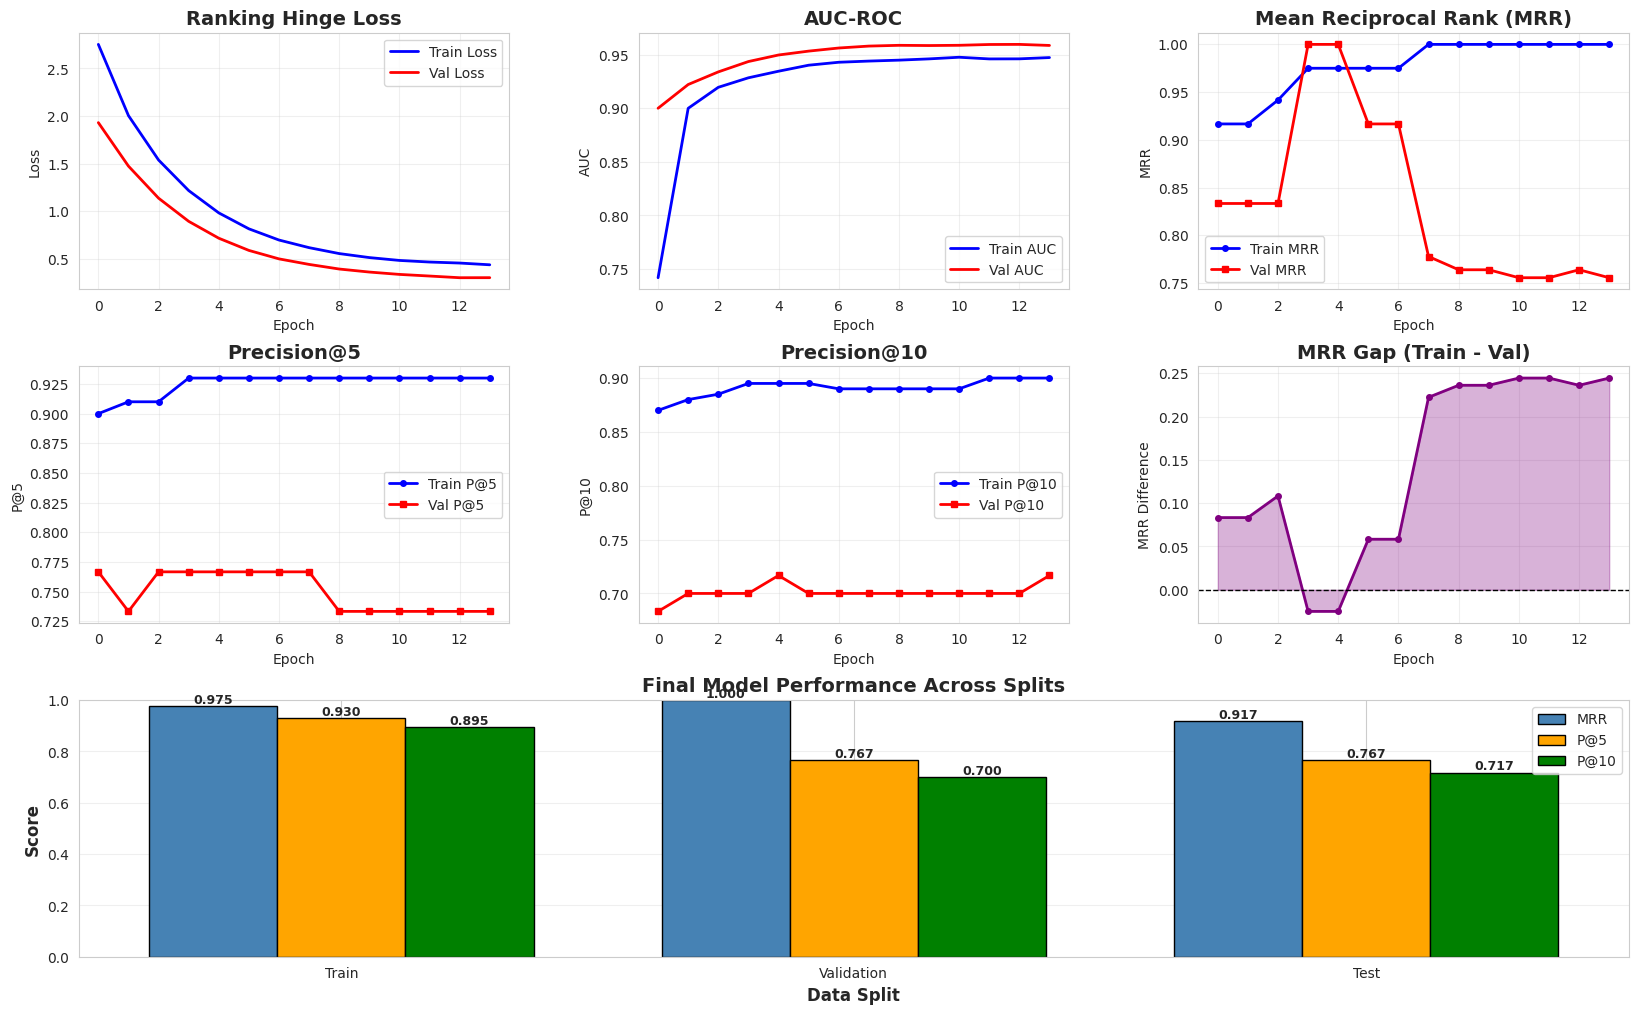

In [150]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Loss Curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='red')
ax1.set_title('Ranking Hinge Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. AUC Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['auc'], label='Train AUC', linewidth=2, color='blue')
ax2.plot(history.history['val_auc'], label='Val AUC', linewidth=2, color='red')
ax2.set_title('AUC-ROC', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. MRR Learning Curve (Train vs Val)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(ranking_callback.history_data['train_mrr'], label='Train MRR', linewidth=2, color='blue', marker='o', markersize=4)
ax3.plot(ranking_callback.history_data['val_mrr'], label='Val MRR', linewidth=2, color='red', marker='s', markersize=4)
ax3.set_title('Mean Reciprocal Rank (MRR)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('MRR')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Precision@5 Learning Curve
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(ranking_callback.history_data['train_p@5'], label='Train P@5', linewidth=2, color='blue', marker='o', markersize=4)
ax4.plot(ranking_callback.history_data['val_p@5'], label='Val P@5', linewidth=2, color='red', marker='s', markersize=4)
ax4.set_title('Precision@5', fontsize=14, fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('P@5')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Precision@10 Learning Curve
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(ranking_callback.history_data['train_p@10'], label='Train P@10', linewidth=2, color='blue', marker='o', markersize=4)
ax5.plot(ranking_callback.history_data['val_p@10'], label='Val P@10', linewidth=2, color='red', marker='s', markersize=4)
ax5.set_title('Precision@10', fontsize=14, fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('P@10')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. MRR Gap (Train - Val)
ax6 = fig.add_subplot(gs[1, 2])
mrr_gap = [t - v for t, v in zip(ranking_callback.history_data['train_mrr'], ranking_callback.history_data['val_mrr'])]
ax6.plot(mrr_gap, linewidth=2, color='purple', marker='o', markersize=4)
ax6.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax6.set_title('MRR Gap (Train - Val)', fontsize=14, fontweight='bold')
ax6.set_xlabel('Epoch')
ax6.set_ylabel('MRR Difference')
ax6.grid(True, alpha=0.3)
ax6.fill_between(range(len(mrr_gap)), mrr_gap, alpha=0.3, color='purple')

# 7. Final Test Set Performance - Bar Chart
ax7 = fig.add_subplot(gs[2, :])

# Calculate final metrics on all splits
train_rank_final = rank(X_train_scaled, y_train, cv_train, model)
val_rank_final = rank(X_val_scaled, y_val, cv_val, model)
test_rank_final = rank(X_test_scaled, y_test, cv_test, model)

train_mrr_final = mean_reciprocal_rank(train_rank_final)
val_mrr_final = mean_reciprocal_rank(val_rank_final)
test_mrr_final = mean_reciprocal_rank(test_rank_final)

train_p5_final = precision_at_k(train_rank_final, k=5)
val_p5_final = precision_at_k(val_rank_final, k=5)
test_p5_final = precision_at_k(test_rank_final, k=5)

train_p10_final = precision_at_k(train_rank_final, k=10)
val_p10_final = precision_at_k(val_rank_final, k=10)
test_p10_final = precision_at_k(test_rank_final, k=10)

splits = ['Train', 'Validation', 'Test']
mrr_scores = [train_mrr_final, val_mrr_final, test_mrr_final]
p5_scores = [train_p5_final, val_p5_final, test_p5_final]
p10_scores = [train_p10_final, val_p10_final, test_p10_final]

x = np.arange(len(splits))
width = 0.25

bars1 = ax7.bar(x - width, mrr_scores, width, label='MRR', color='steelblue', edgecolor='black')
bars2 = ax7.bar(x, p5_scores, width, label='P@5', color='orange', edgecolor='black')
bars3 = ax7.bar(x + width, p10_scores, width, label='P@10', color='green', edgecolor='black')

ax7.set_xlabel('Data Split', fontsize=12, fontweight='bold')
ax7.set_ylabel('Score', fontsize=12, fontweight='bold')
ax7.set_title('Final Model Performance Across Splits', fontsize=14, fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(splits)
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')
ax7.set_ylim([0, 1.0])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

In [151]:
print("MODEL PERFORMANCE SUMMARY")

print(f"\n{'Metric':<20} {'Train':<15} {'Validation':<15} {'Test':<15}")
print("-"*70)
print(f"{'MRR':<20} {train_mrr_final:<15.4f} {val_mrr_final:<15.4f} {test_mrr_final:<15.4f}")
print(f"{'Precision@5':<20} {train_p5_final:<15.4f} {val_p5_final:<15.4f} {test_p5_final:<15.4f}")
print(f"{'Precision@10':<20} {train_p10_final:<15.4f} {val_p10_final:<15.4f} {test_p10_final:<15.4f}")
print(f"{'AUC':<20} {history.history['auc'][-1]:<15.4f} {history.history['val_auc'][-1]:<15.4f} {roc_auc_score(y_test, model.predict(X_test_scaled)):<15.4f}")

print("\n" + "="*70)
print(f"Training completed in {len(history.history['loss'])} epochs")
print(f"Best epoch (by validation AUC): {np.argmax(history.history['val_auc']) + 1}")
print("="*70)

MODEL PERFORMANCE SUMMARY

Metric               Train           Validation      Test           
----------------------------------------------------------------------
MRR                  0.9750          1.0000          0.9167         
Precision@5          0.9300          0.7667          0.7667         
Precision@10         0.8950          0.7000          0.7167         
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
AUC                  0.9473          0.9586          0.9595         

Training completed in 14 epochs
Best epoch (by validation AUC): 13


In [152]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

In [153]:
k_values = range(1, 31)
val_auc_scores = []
train_auc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
        weights='uniform'
    )
    knn.fit(X_train_scaled, y_train)

    train_probs = knn.predict_proba(X_train_scaled)[:, 1]
    val_probs = knn.predict_proba(X_val_scaled)[:, 1]

    train_auc_scores.append(roc_auc_score(y_train, train_probs))
    val_auc_scores.append(roc_auc_score(y_val, val_probs))

best_k = k_values[np.argmax(val_auc_scores)]
print(f"Best k (by Validation AUC): {best_k}")

Best k (by Validation AUC): 14


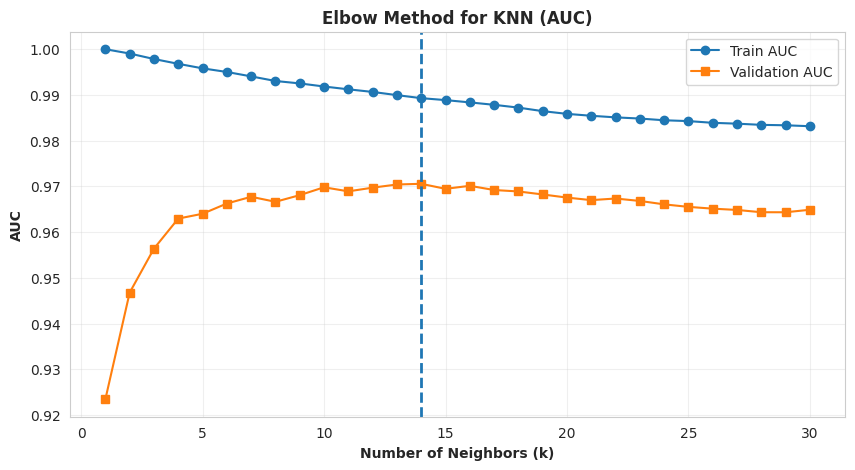

In [154]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_auc_scores, marker='o', label='Train AUC')
plt.plot(k_values, val_auc_scores, marker='s', label='Validation AUC')
plt.axvline(best_k, linestyle='--', linewidth=2)
plt.xlabel('Number of Neighbors (k)', fontweight='bold')
plt.ylabel('AUC', fontweight='bold')
plt.title('Elbow Method for KNN (AUC)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [155]:
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='uniform'
)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=14)

In [156]:
train_probs = knn.predict_proba(X_train_scaled)[:, 1]
val_probs   = knn.predict_proba(X_val_scaled)[:, 1]
test_probs  = knn.predict_proba(X_test_scaled)[:, 1]

train_preds = (train_probs >= 0.5).astype(int)
val_preds   = (val_probs >= 0.5).astype(int)
test_preds  = (test_probs >= 0.5).astype(int)

In [157]:
train_auc = roc_auc_score(y_train, train_probs)
val_auc   = roc_auc_score(y_val, val_probs)
test_auc  = roc_auc_score(y_test, test_probs)

train_ap = average_precision_score(y_train, train_probs)
val_ap   = average_precision_score(y_val, val_probs)
test_ap  = average_precision_score(y_test, test_probs)

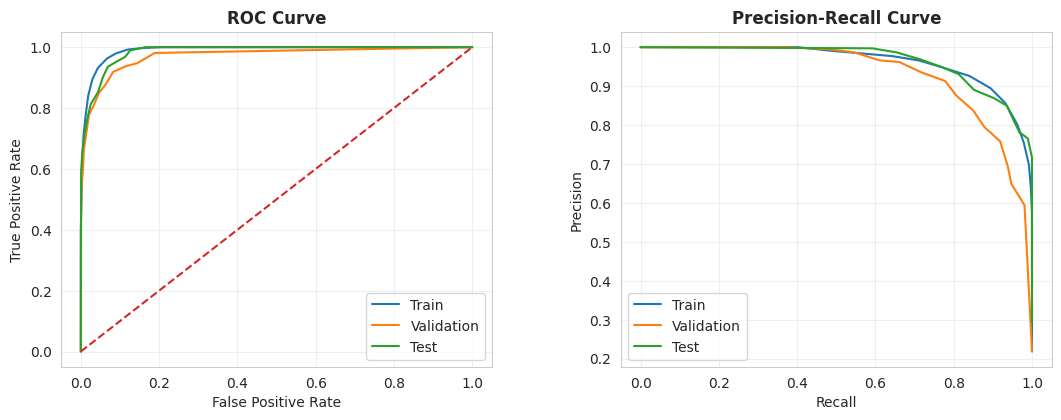

In [158]:
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
for y_true, y_prob, label in [
    (y_train, train_probs, 'Train'),
    (y_val, val_probs, 'Validation'),
    (y_test, test_probs, 'Test')
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax1.plot(fpr, tpr, label=label)

ax1.plot([0, 1], [0, 1], linestyle='--')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve
ax2 = fig.add_subplot(gs[0, 1])
for y_true, y_prob, label in [
    (y_train, train_probs, 'Train'),
    (y_val, val_probs, 'Validation'),
    (y_test, test_probs, 'Test')
]:
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ax2.plot(recall, precision, label=label)

ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(True, alpha=0.3)

Text(0, 0.5, 'Actual')

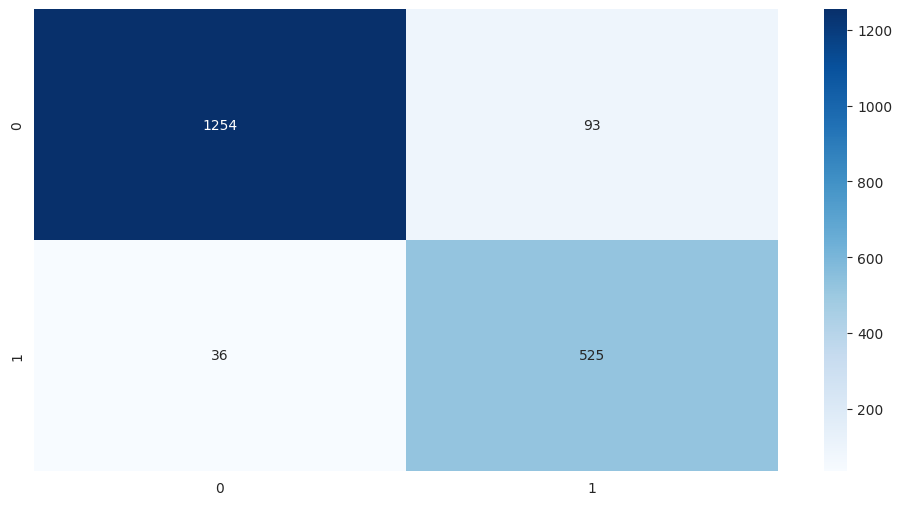

In [159]:
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(
    confusion_matrix(y_test, test_preds),
    annot=True, fmt='d', cmap='Blues'
)
ax3.set_title('Test Confusion Matrix', fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

In [161]:
ax4 = fig.add_subplot(gs[1, :])

splits = ['Train', 'Validation', 'Test']
auc_scores = [train_auc, val_auc, test_auc]
ap_scores = [train_ap, val_ap, test_ap]

x = np.arange(len(splits))
width = 0.35

bars1 = ax4.bar(x - width/2, auc_scores, width, label='AUC', edgecolor='black')
bars2 = ax4.bar(x + width/2, ap_scores, width, label='Avg Precision', edgecolor='black')

ax4.set_xticks(x)
ax4.set_xticklabels(splits)
ax4.set_ylim([0, 1.0])
ax4.set_title('Final KNN Performance Across Splits', fontweight='bold')
ax4.set_ylabel('Score', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        ax4.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.3f}",
            ha='center',
            va='bottom',
            fontweight='bold'
        )

plt.show()

In [162]:
print("\nTRAIN REPORT\n")
print(classification_report(y_train, train_preds))

print("\nVALIDATION REPORT\n")
print(classification_report(y_val, val_preds))

print("\nTEST REPORT\n")
print(classification_report(y_test, test_preds))

print("\nSUMMARY")
print("="*60)
print(f"{'Split':<15}{'AUC':<10}{'Avg Precision'}")
print("-"*60)
print(f"{'Train':<15}{train_auc:<10.4f}{train_ap:.4f}")
print(f"{'Validation':<15}{val_auc:<10.4f}{val_ap:.4f}")
print(f"{'Test':<15}{test_auc:<10.4f}{test_ap:.4f}")
print("="*60)


TRAIN REPORT

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4973
           1       0.89      0.89      0.89      1387

    accuracy                           0.95      6360
   macro avg       0.93      0.93      0.93      6360
weighted avg       0.95      0.95      0.95      6360


VALIDATION REPORT

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1489
           1       0.88      0.81      0.84       419

    accuracy                           0.93      1908
   macro avg       0.91      0.89      0.90      1908
weighted avg       0.93      0.93      0.93      1908


TEST REPORT

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1347
           1       0.85      0.94      0.89       561

    accuracy                           0.93      1908
   macro avg       0.91      0.93      0.92      1908
weighted avg       0.94  